In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 3-cü quyu ucun PBU 
well_name = 'well_3'
file_path = r"C:\Users\Amin\Downloads\data\data\Section 1\well_03_DHP_data..csv"

ts_col = 'Timestamp'
pr_col = 'DHP'

# task kriteriyalari
min_rise_psi   = 600   # en az 600 psi artis
min_duration_h = 2     # en az 2 saat davamliliq

# signal processing parameters
median_window = '20min'   # noise temizleme (median filter)
mean_window   = '10min'   # additional smoothing
noise_mult    = 4.0       # decline_tol = noise_mult * approximate noise
min_decline_tol = 15.0    # decline_tol bu deyerin altina dusmesin

# outlier temizleme 
outlier_window     = 5      # nece qonsu noqte ile lokal medyan hesablanacaq
outlier_threshold  = 500    # lokal medyandan bu qeder (psi) uzaqlasan noqteler atilir

# stagnation limit (hereketsizlik limiti)
max_stagnant_hours = 6 #eger 6 saatdan artiq artis olmadan zaman kecerse PBU sifirlanir
min_valid_psi=100
trough_reset_hours=3

In [2]:
def remove_outliers(df, pr_col='pressure', window=outlier_window, threshold_psi=outlier_threshold):
    #sensor glitch-leri temizlenir (sensordaki ani sicramalar)
    local_median = df[pr_col].rolling(window, center=True, min_periods=1).median()
    deviation = (df[pr_col] - local_median).abs()
    mask = deviation > threshold_psi
    n_out = int(mask.sum())
    if n_out:
        df = df.loc[~mask].copy()
    return df


def load_well_data(filepath, ts_col=ts_col, pr_col=pr_col):
    try:
        df = pd.read_csv(filepath, usecols=[ts_col, pr_col], engine='pyarrow')
    except Exception:
        df = pd.read_csv(filepath, usecols=[ts_col, pr_col])

    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')

    #menfi sonsuzluq kimi deyerler varsa, o deyerleri kecir, hesablamaya almir
    n_inf = np.isinf(df[pr_col]).sum()
    if n_inf:
        df.loc[np.isinf(df[pr_col]), pr_col] = np.nan

    #NaN deyerler hesablamadan kenar qalir
    n_nan_pressure = df[pr_col].isna().sum()
    if n_nan_pressure:
        df = df.dropna(subset=[pr_col])

    #100 psi-den asagi tezyiq deyerleri hesablamaya alinmir
    n_floor = int((df[pr_col] < min_valid_psi).sum())
    if n_floor:
        df = df[df[pr_col] >= min_valid_psi]

    df[pr_col] = df[pr_col].astype('float32')

    #timestamp sutununda bezi deyerlerde zamanin yaninda birlesik qalan T herflerini silib, datetime formatina cevirme
    ts_raw = df[ts_col].astype(str).str.strip()
    ts_raw = ts_raw.str.replace(r'(\d)T$', r'\1', regex=True)
    df[ts_col] = pd.to_datetime(ts_raw, format="mixed", errors='coerce')

    #eger yene ayird edile bilmeyen tarix deyerleri qalarsa atilir
    n_bad_ts = df[ts_col].isna().sum()
    if n_bad_ts:
        df = df.dropna(subset=[ts_col])

    df = df.rename(columns={ts_col: 'timestamp', pr_col: 'pressure'})
    df = (df.sort_values('timestamp')
            .drop_duplicates(subset='timestamp')
            .set_index('timestamp'))

    df = remove_outliers(df)
    return df

In [3]:
#raw data haqqinda melumat almaq 
df = load_well_data(file_path)

print(f'rows: {len(df):,}')
print(f'date range: {df.index.min()}  ->  {df.index.max()}')
print(f'pressure range: {df["pressure"].min():.1f} - {df["pressure"].max():.1f} psi')
df.head()

rows: 18,487,157
date range: 2015-02-18 12:46:26.625000  ->  2024-10-30 13:10:18.731000
pressure range: 1596.0 - 9049.8 psi


,pressure
timestamp,
2015-02-18 12:46:26.625,"4,361.29"
2015-02-18 12:46:56.935,"4,361.33"
2015-02-18 12:48:53.171,"4,361.34"
2015-02-18 13:47:54.393,"4,361.46"
2015-02-18 13:47:59.463,"4,361.67"


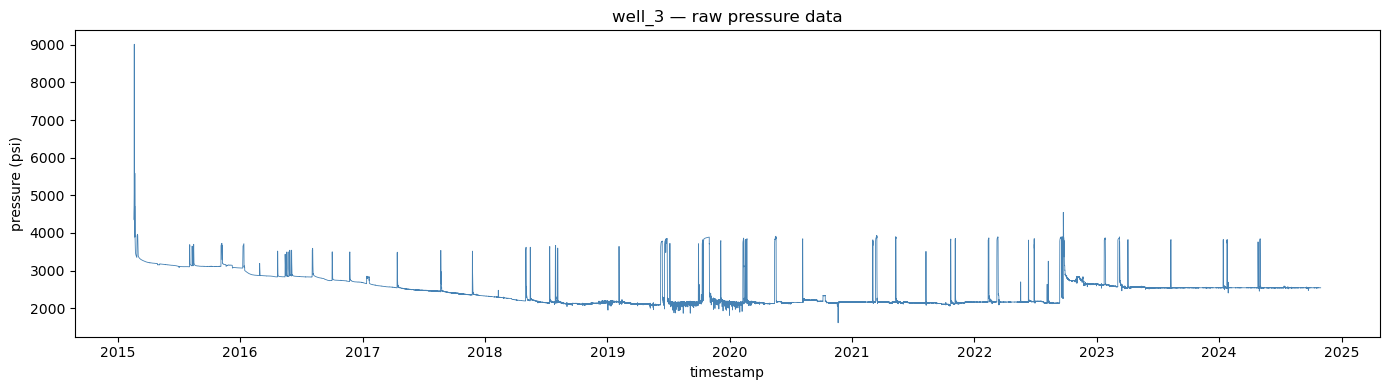

In [4]:
#raw data-ni vizuallasdirma
fig, ax = plt.subplots(figsize=(14, 4))
sample_step = max(1, len(df) // 200_000)
ax.plot(df.index[::sample_step], df['pressure'].values[::sample_step], lw=0.6, color='steelblue')
ax.set_title(f'{well_name} — raw pressure data')
ax.set_xlabel('timestamp')
ax.set_ylabel('pressure (psi)')
plt.tight_layout()
plt.show()

In [5]:
#smoothing/noise cleaning (rolling median + rolling mean)
def smooth_pressure(df, med_win=median_window, mean_win=mean_window):
    s = df['pressure'].rolling(med_win, min_periods=1).median()
    s = s.rolling(mean_win, min_periods=1).mean()
    return s.astype('float32')
smoothed = smooth_pressure(df)

In [6]:
#well_3-e ozel noise level ve düşüş toleransi (decline_tol) hesablama
def estimate_noise_level(smoothed, window='15min', quantile=0.2):
    rolling_std = smoothed.rolling(window, min_periods=5).std()
    noise = rolling_std.quantile(quantile)
    if pd.isna(noise) or noise <= 0:
        noise = smoothed.diff().abs().median() * 3
    return float(noise)

noise = estimate_noise_level(smoothed)
decline_tol = max(min_decline_tol, noise_mult * noise)

In [7]:
def detect_pbus_zigzag(smoothed, decline_tol, min_rise=min_rise_psi,
                        min_duration_hours=min_duration_h,
                        max_stagnant_hours=max_stagnant_hours,
                        trough_reset_hours=trough_reset_hours):
    idx = smoothed.index
    vals = smoothed.values
    n = len(vals)
    max_stagnant = pd.Timedelta(hours=max_stagnant_hours)
    trough_reset = pd.Timedelta(hours=trough_reset_hours)

    results = []
    trough_i, trough_v = 0, vals[0]
    peak_i,   peak_v   = 0, vals[0]
    last_move_i = 0
    state = 'seeking'

    for i in range(1, n):
        v = vals[i]

        if state == 'seeking':
            if v - trough_v >= decline_tol:
                #yukselis basladi
                peak_v, peak_i = v, i
                last_move_i = i
                state = 'rising'
            elif v <= trough_v:
                trough_v, trough_i = v, i
            elif (idx[i] - idx[trough_i]) > trough_reset:
                #uzun muddet yukselis olmadi
                #movcud noqteden yeniden hesablamaga basla
                trough_v, trough_i = v, i

        elif state == 'rising':
            closed = False

            if v > peak_v:
                peak_v, peak_i = v, i
                last_move_i = i

            elif peak_v - v >= decline_tol:
                exact_start, exact_end = idx[trough_i], idx[peak_i]
                duration_h = (exact_end - exact_start).total_seconds() / 3600
                rise = peak_v - trough_v
                if duration_h >= min_duration_hours and rise >= min_rise:
                    results.append({
                        'exact_start': exact_start,
                        'interval_start': exact_start - pd.Timedelta(hours=1.5),
                        'exact_end': exact_end,
                        'interval_end': exact_end + pd.Timedelta(hours=1.5),
                        'duration_hours': round(duration_h, 3),
                        'pressure_change_psi': round(float(rise), 2),
                    })
                trough_v, trough_i = v, i
                state = 'seeking'
                closed = True

            if not closed and (idx[i] - idx[last_move_i]) > max_stagnant:
                exact_start, exact_end = idx[trough_i], idx[peak_i]
                duration_h = (exact_end - exact_start).total_seconds() / 3600
                rise = peak_v - trough_v
                if duration_h >= min_duration_hours and rise >= min_rise:
                    results.append({
                        'exact_start': exact_start,
                        'interval_start': exact_start - pd.Timedelta(hours=1.5),
                        'exact_end': exact_end,
                        'interval_end': exact_end + pd.Timedelta(hours=1.5),
                        'duration_hours': round(duration_h, 3),
                        'pressure_change_psi': round(float(rise), 2),
                    })
                trough_v, trough_i = v, i
                state = 'seeking'

    return pd.DataFrame(results)


result_df = detect_pbus_zigzag(smoothed, decline_tol=decline_tol)
result_df = result_df.sort_values('exact_start').reset_index(drop=True)

print(f'{len(result_df)} PBUs detected for {well_name}.')
result_df

56 PBUs detected for well_3.


,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,2015-02-26 22:02:50.577,2015-02-26 20:32:50.577,2015-02-28 13:15:03.526,2015-02-28 14:45:03.526,39.20,611.21
1,2015-11-04 16:56:06.900,2015-11-04 15:26:06.900,2015-11-07 16:38:49.600,2015-11-07 18:08:49.600,71.71,616.59
2,2016-01-09 02:08:37.800,2016-01-09 00:38:37.800,2016-01-12 04:45:20.600,2016-01-12 06:15:20.600,74.61,658.92
3,2016-04-21 18:38:32.200,2016-04-21 17:08:32.200,2016-04-22 01:19:57.300,2016-04-22 02:49:57.300,6.69,690.21
4,2016-05-14 07:17:56.400,2016-05-14 05:47:56.400,2016-05-14 10:23:29.300,2016-05-14 11:53:29.300,3.09,625.62
5,2016-05-19 10:40:19.400,2016-05-19 09:10:19.400,2016-05-19 13:21:20.500,2016-05-19 14:51:20.500,2.68,642.36
6,2016-05-25 18:36:37.500,2016-05-25 17:06:37.500,2016-05-25 21:12:46.900,2016-05-25 22:42:46.900,2.60,652.46
7,2016-05-28 00:54:32.800,2016-05-27 23:24:32.800,2016-05-28 07:01:46.300,2016-05-28 08:31:46.300,6.12,686.39
8,2016-06-02 09:25:50.800,2016-06-02 07:55:50.800,2016-06-02 16:40:46.000,2016-06-02 18:10:46.000,7.25,697.04
9,2016-08-02 21:16:10.100,2016-08-02 19:46:10.100,2016-08-04 15:11:46.100,2016-08-04 16:41:46.100,41.93,763.38


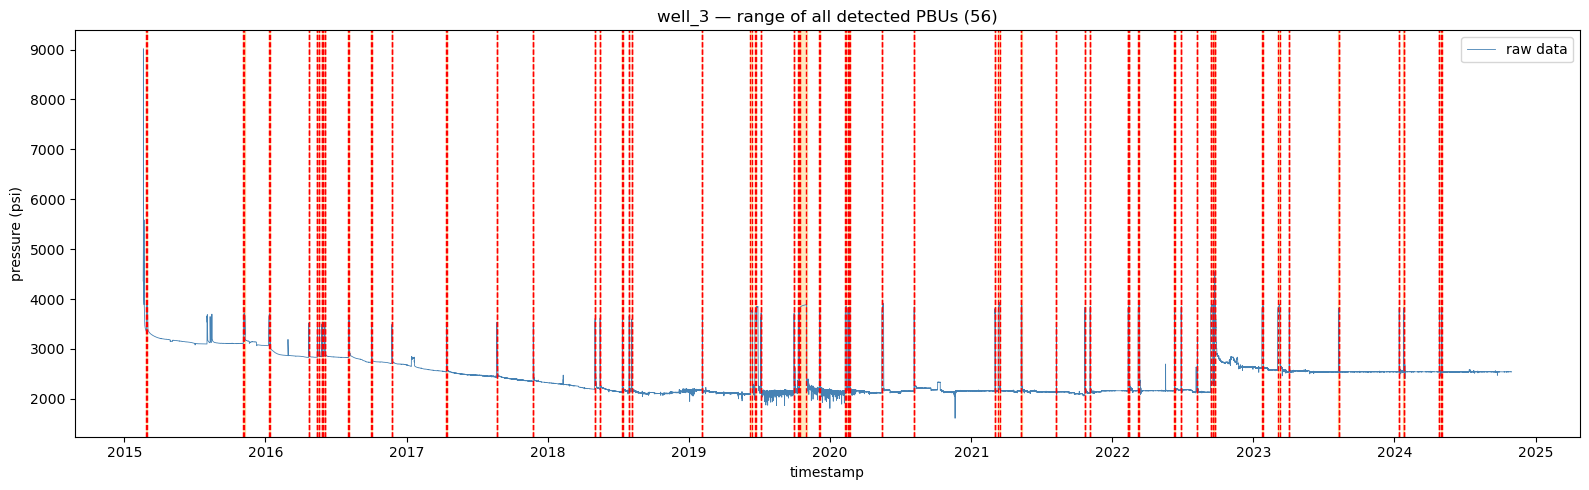

In [8]:
def plot_all_pbus(df, result_df, well_name, max_points=200_000):
    sample_step = max(1, len(df) // max_points)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df.index[::sample_step], df['pressure'].values[::sample_step],
            color='steelblue', lw=0.6, label='raw data')

    for _, row in result_df.iterrows():
        ax.axvspan(row['interval_start'], row['interval_end'], color='orange', alpha=0.25)
        ax.axvline(row['exact_start'], color='red', ls='--', lw=1)
        ax.axvline(row['exact_end'], color='red', ls='--', lw=1)

    ax.set_title(f'{well_name} — range of all detected PBUs ({len(result_df)})')
    ax.set_xlabel('timestamp')
    ax.set_ylabel('pressure (psi)')
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_all_pbus(df, result_df, well_name)

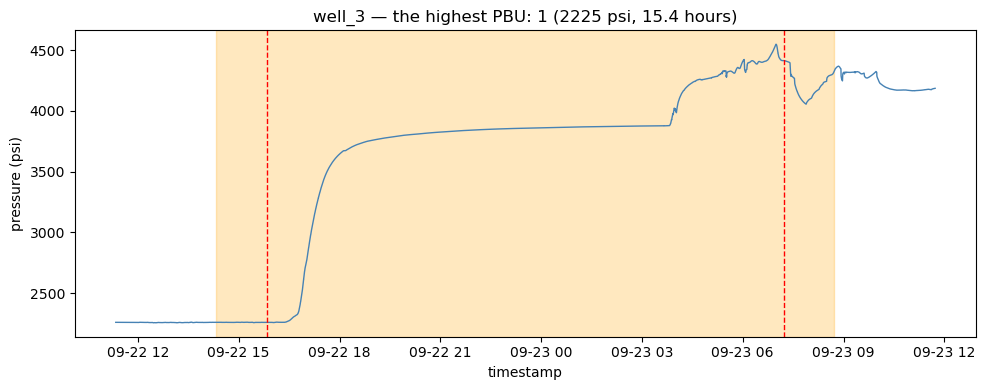

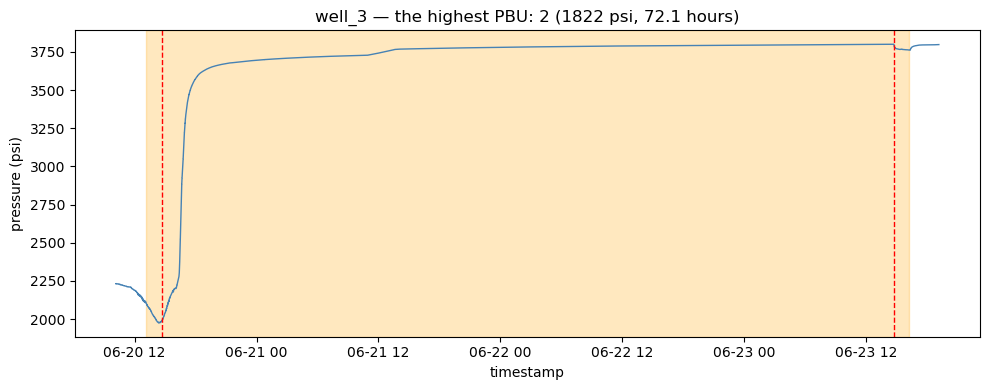

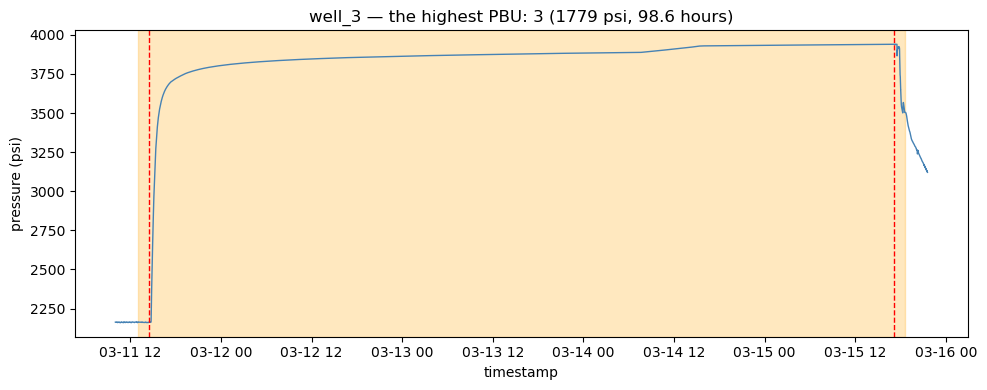

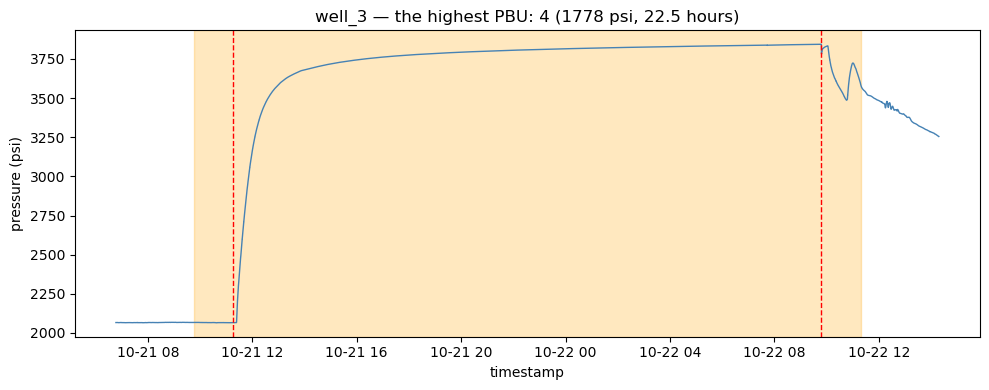

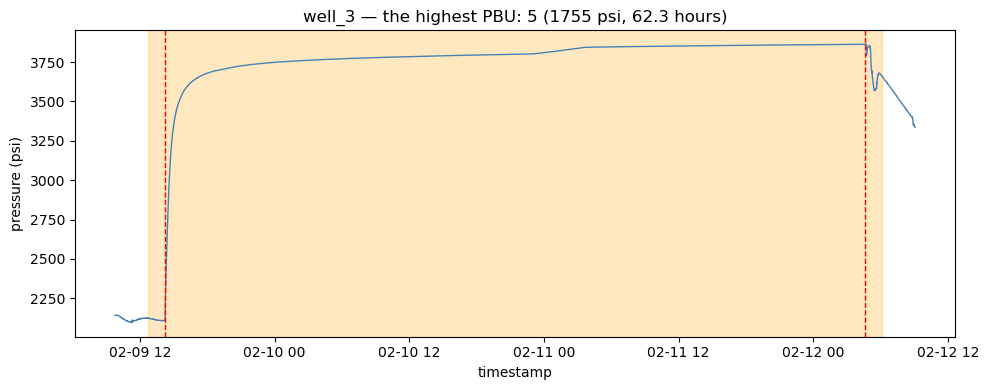

In [9]:
#en yüksek 5 PBU-yu detalli vizuallasdirma
def plot_top_pbus(df, result_df, well_name, top_n=5, criterion='pressure_change_psi', margin_hours=3):
    if result_df.empty:
        print(f'{well_name}: not found PBU.')
        return

    top = result_df.sort_values(criterion, ascending=False).head(top_n)

    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        margin = pd.Timedelta(hours=margin_hours)
        window = df.loc[row['interval_start'] - margin: row['interval_end'] + margin]

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(window.index, window['pressure'].values, color='steelblue', lw=1.0)
        ax.axvspan(row['interval_start'], row['interval_end'], color='orange', alpha=0.25)
        ax.axvline(row['exact_start'], color='red', ls='--', lw=1)
        ax.axvline(row['exact_end'], color='red', ls='--', lw=1)

        ax.set_title(
            f'{well_name} — the highest PBU: {rank} '
            f'({row["pressure_change_psi"]:.0f} psi, {row["duration_hours"]:.1f} hours)'
        )
        ax.set_xlabel('timestamp')
        ax.set_ylabel('pressure (psi)')
        plt.tight_layout()
        plt.show()

plot_top_pbus(df, result_df, well_name, top_n=5)

interval_start    2022-09-22 14:20:06
exact_start       2022-09-22 15:50:06
exact_end         2022-09-23 07:13:37
interval_end      2022-09-23 08:43:37
Name: 47, dtype: object
count   5,287.00
mean    2,274.93
std        14.21
min     2,258.48
25%     2,260.83
50%     2,265.63
75%     2,290.41
max     2,293.31
Name: pressure, dtype: float64


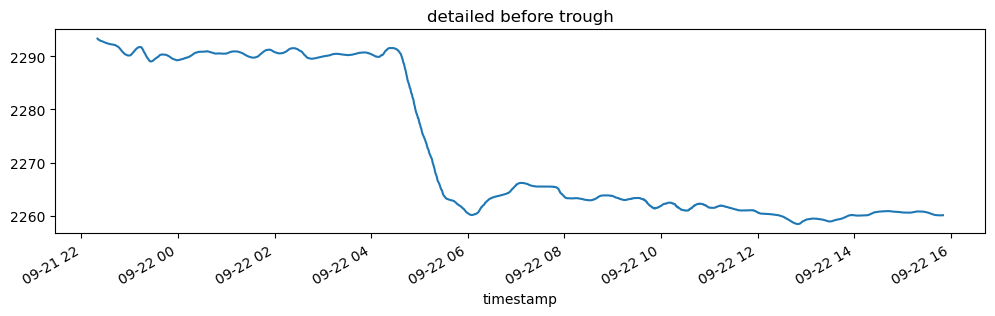

In [10]:
#bu ve asagidaki blok sadece islerin duzgun getdiyinden emin olmaq ucun yazilmisdir
# result_df icindeki 1-ci PBU-nun tam interval_start / exact_start deyerlerini goster
row1 = result_df.sort_values('pressure_change_psi', ascending=False).iloc[0]
print(row1[['interval_start', 'exact_start', 'exact_end', 'interval_end']])

#o araliqdan tam evvelki hisseni zamaniyla birlikde goster
window = smoothed.loc[row1['interval_start'] - pd.Timedelta(hours=16): row1['exact_start']]
window.plot(figsize=(12,3), title='detailed before trough')
print(window.describe())

interval_start           2019-06-20 13:09:09
exact_start              2019-06-20 14:39:09
exact_end         2019-06-23 14:44:49.974000
interval_end      2019-06-23 16:14:49.974000
Name: 22, dtype: object
count   13,753.00
mean     2,205.59
std         49.15
min      1,977.70
25%      2,201.51
50%      2,218.12
75%      2,234.34
max      2,257.81
Name: pressure, dtype: float64


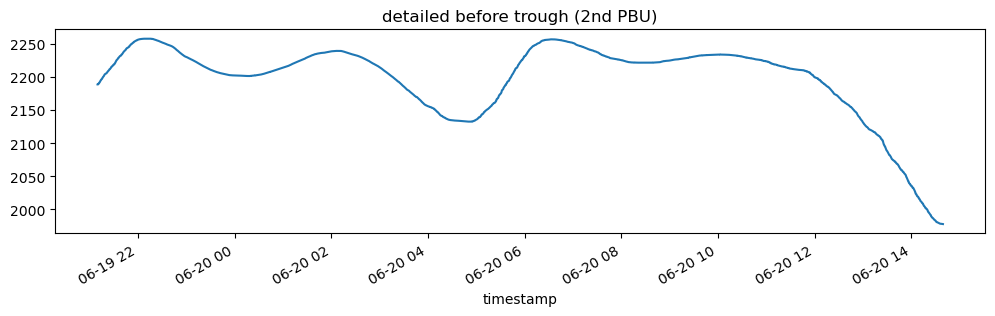

In [11]:
row2 = result_df.sort_values('pressure_change_psi', ascending=False).iloc[1]
print(row2[['interval_start', 'exact_start', 'exact_end', 'interval_end']])

window = smoothed.loc[row2['interval_start'] - pd.Timedelta(hours=16): row2['exact_start']]
window.plot(figsize=(12,3), title='detailed before trough (2nd PBU)')
print(window.describe())

In [12]:
result_df.insert(0, 'well', well_name)
result_df.to_csv(f'{well_name}_pbu_results.csv', index=False)
print(f'saved to {well_name}_pbu_results.csv  ({len(result_df)} PBUs)')
result_df

saved to well_3_pbu_results.csv  (56 PBUs)


,well,exact_start,interval_start,exact_end,interval_end,duration_hours,pressure_change_psi
0,well_3,2015-02-26 22:02:50.577,2015-02-26 20:32:50.577,2015-02-28 13:15:03.526,2015-02-28 14:45:03.526,39.20,611.21
1,well_3,2015-11-04 16:56:06.900,2015-11-04 15:26:06.900,2015-11-07 16:38:49.600,2015-11-07 18:08:49.600,71.71,616.59
2,well_3,2016-01-09 02:08:37.800,2016-01-09 00:38:37.800,2016-01-12 04:45:20.600,2016-01-12 06:15:20.600,74.61,658.92
3,well_3,2016-04-21 18:38:32.200,2016-04-21 17:08:32.200,2016-04-22 01:19:57.300,2016-04-22 02:49:57.300,6.69,690.21
4,well_3,2016-05-14 07:17:56.400,2016-05-14 05:47:56.400,2016-05-14 10:23:29.300,2016-05-14 11:53:29.300,3.09,625.62
5,well_3,2016-05-19 10:40:19.400,2016-05-19 09:10:19.400,2016-05-19 13:21:20.500,2016-05-19 14:51:20.500,2.68,642.36
6,well_3,2016-05-25 18:36:37.500,2016-05-25 17:06:37.500,2016-05-25 21:12:46.900,2016-05-25 22:42:46.900,2.60,652.46
7,well_3,2016-05-28 00:54:32.800,2016-05-27 23:24:32.800,2016-05-28 07:01:46.300,2016-05-28 08:31:46.300,6.12,686.39
8,well_3,2016-06-02 09:25:50.800,2016-06-02 07:55:50.800,2016-06-02 16:40:46.000,2016-06-02 18:10:46.000,7.25,697.04
9,well_3,2016-08-02 21:16:10.100,2016-08-02 19:46:10.100,2016-08-04 15:11:46.100,2016-08-04 16:41:46.100,41.93,763.38


In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

#referans (ground-truth) datani yukle
ref_path = r"C:\Users\Amin\Downloads\data\data\Section 2\well_03_Pressure_data.xlsx"
ref_df = pd.read_excel(ref_path)
ref_df.columns = ['well', 'approx_date', 'reservoir_pressure_true']
ref_df['approx_date'] = pd.to_datetime(ref_df['approx_date'])
ref_df = ref_df.sort_values('approx_date').reset_index(drop=True)

print(f'{len(ref_df)} reference PBUs found.')
ref_df

9 reference PBUs found.


,well,approx_date,reservoir_pressure_true
0,3,2015-02-26,4014
1,3,2016-06-02,3824
2,3,2017-08-21,3812
3,3,2018-07-29,3864
4,3,2019-10-14,3937
5,3,2020-05-14,4033
6,3,2021-03-11,4073
7,3,2023-03-03,3974
8,3,2024-05-01,3970


In [14]:
well3_pbus = result_df.copy().sort_values('exact_start').reset_index(drop=True)

# "tp" (PBU evvelinden production vaxti) = bir onceki PBU-nun bitisinden bu PBU'nun
# baslangicina qeder kecen vaxt. ilk PBU ucun,datanin en basindan etibaren.
well3_pbus['prev_end'] = well3_pbus['exact_end'].shift(1)
well3_pbus.loc[0, 'prev_end'] = well3_pbus.loc[0, 'exact_start'] - pd.Timedelta(days=30)
well3_pbus['tp_hours'] = (well3_pbus['exact_start'] - well3_pbus['prev_end']).dt.total_seconds() / 3600
well3_pbus['tp_hours'] = well3_pbus['tp_hours'].clip(lower=1.0)

# referans tarixlerini en yaxin PBU ile eynilesdir
def find_closest_pbu(approx_date, pbu_df, max_days=15):
    diffs = (pbu_df['exact_start'] - approx_date).abs()
    idx = diffs.idxmin()
    if diffs.loc[idx] > pd.Timedelta(days=max_days):
        return None
    return idx

ref_df['matched_pbu_idx'] = ref_df['approx_date'].apply(lambda d: find_closest_pbu(d, well3_pbus))

n_matched = ref_df['matched_pbu_idx'].notna().sum()
print(f'{n_matched} / {len(ref_df)} reference PBUs matched with the PBUs that detected in section 1.')
ref_df[['approx_date', 'reservoir_pressure_true', 'matched_pbu_idx']]

9 / 9 reference PBUs matched with the PBUs that detected in section 1.


,approx_date,reservoir_pressure_true,matched_pbu_idx
0,2015-02-26,4014,0
1,2016-06-02,3824,8
2,2017-08-21,3812,13
3,2018-07-29,3864,18
4,2019-10-14,3937,26
5,2020-05-14,4033,31
6,2021-03-11,4073,34
7,2023-03-03,3974,49
8,2024-05-01,3970,55


In [15]:
#horner analiz funksiyası
def horner_fit(pbu_row, smoothed, skip_frac=0.7):
#Horner analizi: PDF-deki radial axin dusturunun 
    #(ΔP_radial = -m*ln(tp/Δt+1)) tetbiqi. 
    #P-ni x = ln((tp+Δt)/Δt)-e qarsi xetti uygunlasdirir (fit edir), 
    #x=0 noqtesine (delta t -> sonsuzluq) ekstrapolyasiya ederek 
    #rezervuar tezyiqini tapir.
    #skip_frac: PBU-nun başlangicindaki wellbore storage (quyu hecmi) 
    #effektinden dolayi tehrif olunmus hisseni (məs. ilk 70%-i) 
    #fit-den kenarda saxlayir, yalniz son hisseden istifade edir.
    seg = smoothed.loc[pbu_row['exact_start']:pbu_row['exact_end']]
    dt_hours = (seg.index - pbu_row['exact_start']).total_seconds() / 3600
    y = seg.values.astype(float)
    tp = pbu_row['tp_hours']

    dt_safe = np.clip(dt_hours, 1e-3, None)
    x = np.log((tp + dt_safe) / dt_safe)

    duration = dt_hours.max()
    mask = dt_hours >= skip_frac * duration
    if mask.sum() < 5:
        mask = np.ones_like(dt_hours, dtype=bool)

    x_fit, y_fit = x[mask], y[mask]

    A = np.column_stack([x_fit, np.ones_like(x_fit)])
    (slope, intercept), *_ = np.linalg.lstsq(A, y_fit, rcond=None)

    p_reservoir = intercept
    y_pred_full = intercept + slope * x
    rmse = np.sqrt(np.mean((y - y_pred_full) ** 2))

    return p_reservoir, rmse, (x, y, y_pred_full, mask)

In [16]:
#skip_frac parametrinin (yeni PBU-nun basindaki hansi faizlik hisse 
#fitin kenarinda qalsin) en yaxsi deyerini 9 real PBU uzerinde
#deneme-yanilma (grid search) yontemiyle tapir
matched = ref_df.dropna(subset=['matched_pbu_idx'])
candidate_skips = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

skip_results = []
for sf in candidate_skips:
    errors = []
    for _, ref_row in matched.iterrows():
        pbu_row = well3_pbus.loc[ref_row['matched_pbu_idx']]
        p_est, _, _ = horner_fit(pbu_row, smoothed, skip_frac=sf)
        errors.append(abs(p_est - ref_row['reservoir_pressure_true']))
    skip_results.append({'skip_frac': sf, 'mae': np.mean(errors)})

skip_df = pd.DataFrame(skip_results)
print(skip_df)

best_skip = skip_df.loc[skip_df['mae'].idxmin(), 'skip_frac']
print(f'\n the best skip_frac: {best_skip}  (MAE: {skip_df["mae"].min():.1f} psi)')

   skip_frac    mae
0       0.00 787.18
1       0.10 622.98
2       0.20 101.70
3       0.30  72.59
4       0.40  61.28
5       0.50  59.14
6       0.60  61.65
7       0.70  53.79
8       0.80  98.25

 the best skip_frac: 0.7  (MAE: 53.8 psi)


In [17]:
validation_rows = []
for _, ref_row in ref_df.dropna(subset=['matched_pbu_idx']).iterrows():
    pbu_row = well3_pbus.loc[ref_row['matched_pbu_idx']]
    p_est, rmse, _ = horner_fit(pbu_row, smoothed, skip_frac=best_skip)

    validation_rows.append({
        'approx_date': ref_row['approx_date'],
        'exact_start': pbu_row['exact_start'],
        'true_pressure': ref_row['reservoir_pressure_true'],
        'estimated_pressure': round(p_est, 1),
        'error_psi': round(p_est - ref_row['reservoir_pressure_true'], 1),
        'fit_rmse': round(rmse, 1),
    })

validation_df = pd.DataFrame(validation_rows)
mae = validation_df['error_psi'].abs().mean()
print(f'mean absolute error (MAE): {mae:.1f} psi')
validation_df

mean absolute error (MAE): 53.8 psi


,approx_date,exact_start,true_pressure,estimated_pressure,error_psi,fit_rmse
0,2015-02-26,2015-02-26 22:02:50.577,4014,"4,047.50",33.50,275.30
1,2016-06-02,2016-06-02 09:25:50.800,3824,"3,695.90",-128.10,305.80
2,2017-08-21,2017-08-21 04:22:45.300,3812,"3,846.40",34.40,455.60
3,2018-07-29,2018-07-29 15:28:33.100,3864,"3,793.50",-70.50,655.80
4,2019-10-14,2019-10-14 11:17:14.000,3937,"3,911.80",-25.20,206.10
5,2020-05-14,2020-05-14 07:03:01.600,4033,"4,086.60",53.60,"1,054.50"
6,2021-03-11,2021-03-11 14:30:15.000,4073,"4,055.60",-17.40,597.60
7,2023-03-03,2023-03-04 17:51:37.000,3974,"3,938.00",-36.00,389.80
8,2024-05-01,2024-05-01 08:01:14.692,3970,"3,884.60",-85.40,358.00


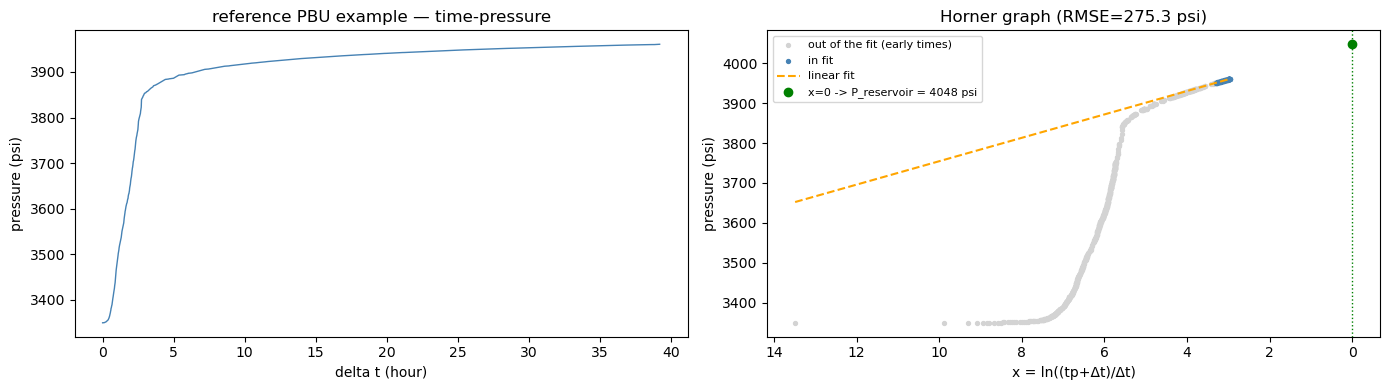

In [19]:
def plot_horner_fit(pbu_row, smoothed, skip_frac=best_skip, label=''):
    p_est, rmse, (x, y, y_pred, mask) = horner_fit(pbu_row, smoothed, skip_frac=skip_frac)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    dt_hours = (smoothed.loc[pbu_row['exact_start']:pbu_row['exact_end']].index
                - pbu_row['exact_start']).total_seconds() / 3600
    axes[0].plot(dt_hours, y, color='steelblue', lw=1)
    axes[0].set_title(f'{label} — time-pressure')
    axes[0].set_xlabel('delta t (hour)')
    axes[0].set_ylabel('pressure (psi)')

    axes[1].scatter(x[~mask], y[~mask], s=8, color='lightgray', label='out of the fit (early times)')
    axes[1].scatter(x[mask], y[mask], s=8, color='steelblue', label='in fit')
    axes[1].plot(x, y_pred, color='orange', ls='--', lw=1.5, label='linear fit')
    axes[1].axvline(0, color='green', ls=':', lw=1)
    axes[1].scatter([0], [p_est], color='green', zorder=5,
                     label=f'x=0 -> P_reservoir = {p_est:.0f} psi')
    axes[1].set_title(f'Horner graph (RMSE={rmse:.1f} psi)')
    axes[1].set_xlabel('x = ln((tp+Δt)/Δt)')
    axes[1].set_ylabel('pressure (psi)')
    axes[1].legend(fontsize=8)
    axes[1].invert_xaxis()

    plt.tight_layout()
    plt.show()

first_matched = ref_df.dropna(subset=['matched_pbu_idx']).iloc[0]
plot_horner_fit(well3_pbus.loc[first_matched['matched_pbu_idx']], smoothed, label='reference PBU example')

In [20]:
def safe_estimate_reservoir_pressure(pbu_row, smoothed, skip_frac=best_skip,
                                       max_deviation_psi=400, min_tail_points=5):
    #Horner texminini hesablama; eger texmin fiziki olaraq mentiqsizdirse
    #(oz quyruq ortalamasindan cox kenara cixirsa, ya da fit ucun kifayet
    #qederr noqte yoxdursa) daha sabit olan 'quyruq ortalamasi' usuluna kecir
    seg = smoothed.loc[pbu_row['exact_start']:pbu_row['exact_end']]
    dt_hours = (seg.index - pbu_row['exact_start']).total_seconds() / 3600
    duration = dt_hours.max()

    tail_mask = dt_hours >= skip_frac * duration
    tail_mean = seg.values[tail_mask].mean() if tail_mask.sum() > 0 else seg.values[-5:].mean()

    p_est, rmse, _ = horner_fit(pbu_row, smoothed, skip_frac=skip_frac)

    n_tail_points = int(tail_mask.sum())
    deviation = abs(p_est - tail_mean)

    if n_tail_points < min_tail_points or deviation > max_deviation_psi:
        return tail_mean, rmse, 'tail_mean_fallback'
    return p_est, rmse, 'horner'


final_rows = []
for i, pbu_row in well3_pbus.iterrows():
    p_est, rmse, method = safe_estimate_reservoir_pressure(pbu_row, smoothed, skip_frac=best_skip)

    match = ref_df[ref_df['matched_pbu_idx'] == i]
    true_val = match['reservoir_pressure_true'].values[0] if len(match) else np.nan

    final_rows.append({
        'well': 'well_3',
        'exact_start': pbu_row['exact_start'],
        'exact_end': pbu_row['exact_end'],
        'duration_hours': pbu_row['duration_hours'],
        'pressure_change_psi': pbu_row['pressure_change_psi'],
        'tp_hours': round(pbu_row['tp_hours'], 1),
        'estimated_reservoir_pressure': round(p_est, 1),
        'fit_rmse': round(rmse, 1),
        'method_used': method,
        'is_ground_truth': not pd.isna(true_val),
        'ground_truth_pressure': true_val,
    })

section2_results = pd.DataFrame(final_rows)
section2_results.to_csv('well_3_reservoir_pressure_estimates.csv', index=False)

n_fallback = (section2_results['method_used'] == 'tail_mean_fallback').sum()
print(f'reservoir pressure was estimated for a total of {len(section2_results)} PBUs.')
print(f'  -{len(section2_results) - n_fallback} of them using Horner analysis,')
print(f'  -{n_fallback} of them calculated using tail average (due to giving unreasonable Horner results).')
print('Kaydedildi: well_3_reservoir_pressure_estimates.csv')
section2_results

reservoir pressure was estimated for a total of 56 PBUs.
  -49 of them using Horner analysis,
  -7 of them calculated using tail average (due to giving unreasonable Horner results).
Kaydedildi: well_3_reservoir_pressure_estimates.csv


,well,exact_start,exact_end,duration_hours,pressure_change_psi,tp_hours,estimated_reservoir_pressure,fit_rmse,method_used,is_ground_truth,ground_truth_pressure
0,well_3,2015-02-26 22:02:50.577,2015-02-28 13:15:03.526,39.20,611.21,720.00,"4,047.50",275.30,horner,True,"4,014.00"
1,well_3,2015-11-04 16:56:06.900,2015-11-07 16:38:49.600,71.71,616.59,"5,979.70","3,883.60",123.60,horner,False,NaN
2,well_3,2016-01-09 02:08:37.800,2016-01-12 04:45:20.600,74.61,658.92,"1,497.50","3,856.80",17.90,horner,False,NaN
3,well_3,2016-04-21 18:38:32.200,2016-04-22 01:19:57.300,6.69,690.21,"2,413.90","3,899.10",333.90,horner,False,NaN
4,well_3,2016-05-14 07:17:56.400,2016-05-14 10:23:29.300,3.09,625.62,534.00,"3,402.30",297.90,tail_mean_fallback,False,NaN
5,well_3,2016-05-19 10:40:19.400,2016-05-19 13:21:20.500,2.68,642.36,120.30,"3,689.20",306.00,horner,False,NaN
6,well_3,2016-05-25 18:36:37.500,2016-05-25 21:12:46.900,2.60,652.46,149.30,"3,781.80",289.30,horner,False,NaN
7,well_3,2016-05-28 00:54:32.800,2016-05-28 07:01:46.300,6.12,686.39,51.70,"3,654.80",230.00,horner,False,NaN
8,well_3,2016-06-02 09:25:50.800,2016-06-02 16:40:46.000,7.25,697.04,122.40,"3,695.90",305.80,horner,True,"3,824.00"
9,well_3,2016-08-02 21:16:10.100,2016-08-04 15:11:46.100,41.93,763.38,"1,468.60","3,749.50",249.60,horner,False,NaN
